<!-- notebook-header -->
# Otimizacao de Codigo Python para ML

**Modulo:** 04 - Deep Learning  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Profiling, vetorizacao, memoria, paralelismo e melhoria de performance em pipelines.


# Otimizacao de Codigo Python para ML

**Objetivo:** Dominar tecnicas de otimizacao de codigo Python -- profiling,
vetorizacao, caching, paralelismo e otimizacao de Pandas -- para acelerar
pipelines de Machine Learning.

## Pre-requisitos e Fio Narrativo

| Voce precisa saber | Notebook de referencia |
|---|---|
| NumPy e operacoes vetoriais | 0_3 NumPy |
| Pandas para manipulacao de dados | 0_5 Pandas |
| CPU vs GPU e conceitos de hardware | 4_5 Aceleracao Hardware |

**Fio narrativo:** em 4_5 vimos como hardware (GPU, TPU) acelera treinamento.
Mas antes de comprar hardware caro, ha muito a ganhar otimizando o *software*.
Um loop Python pode ser 1000x mais lento que o equivalente vetorizado --
e essa otimizacao eh gratis. Aqui aprendemos a encontrar gargalos e elimina-los.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import functools
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

## 1. Profiling: Encontrar Antes de Otimizar

**Analogia:** um medico nunca opera sem diagnosticar primeiro. Profiling eh o
"exame de sangue" do seu codigo -- mostra exatamente onde esta o problema.

**Definicao formal:** profiling mede tempo e memoria gastos em cada parte do codigo.
Ferramentas principais:
- `cProfile`: tempo por funcao (stdlib, sempre disponivel)
- `line_profiler`: tempo por linha (precisa instalar)
- `memory_profiler`: uso de memoria por linha
- `%%timeit`: benchmarking rapido em Jupyter

### Por que em ML?

- A regra 80/20 se aplica: 80% do tempo esta em 20% do codigo
- Otimizar sem profiling eh como atirar no escuro -- voce pode acelerar algo que nao importa
- Em pipelines de ML, o gargalo pode estar em preprocessing (Pandas), treinamento (NumPy/PyTorch) ou I/O
- Profiling direciona esforco para onde o impacto eh maximo

In [2]:
def slow_operation(n):
    result = 0
    for i in range(n):
        result += i ** 2
    return result

def medium_operation(n):
    return np.sum(np.arange(n) ** 2)

def fast_operation(n):
    return (n-1) * n * (2*n - 1) // 6

n_values = [100, 1000, 10000, 100000]
results = []

for n in n_values:
    start = time.time()
    slow_operation(n)
    slow_time = time.time() - start
    
    start = time.time()
    medium_operation(n)
    medium_time = time.time() - start
    
    start = time.time()
    fast_operation(n)
    fast_time = time.time() - start
    
    results.append({
        'n': n,
        'Loop Python': slow_time * 1000,
        'NumPy': medium_time * 1000,
        'Formula': fast_time * 1000000
    })

results_df = pd.DataFrame(results)
print('=== Profiling ===')
print(results_df.to_string(index=False))
print('\nLicao: Vectorization eh crucial!')
print(f'Loop Python vs NumPy: {results[3]["Loop Python"] / results[3]["NumPy"]:.1f}x mais lento')
print(f'NumPy vs Formula: {results[3]["NumPy"] / (results[3]["Formula"]/1000):.1f}x mais lento')

=== Profiling ===
     n  Loop Python    NumPy  Formula
   100     0.004768 0.022173 0.000000
  1000     0.034094 0.011921 0.953674
 10000     0.409842 0.063896 1.192093
100000     4.655838 0.231266 0.953674

Licao: Vectorization eh crucial!
Loop Python vs NumPy: 20.1x mais lento
NumPy vs Formula: 242.5x mais lento


### O que observar

- **Loop Python:** tempo cresce linearmente, ~15ms para 100K iteracoes
- **NumPy vetorizado:** ordens de magnitude mais rapido (~0.1ms para 100K)
- **Formula fechada:** tempo constante, independente de N (microsegundos)
- O mesmo resultado pode ter complexidades de implementacao completamente diferentes

### O que concluir

- Sempre questione: "existe uma forma vetorizada ou formula fechada?"
- Profiling revela que loops Python puros sao quase sempre o gargalo
- A diferenca entre implementacoes pode ser 1000x ou mais
- Invest 5 minutos em profiling para economizar horas de otimizacao cega

### Conexao com outros notebooks

- **0_3 NumPy:** vetorizacao eh a ferramenta #1 de otimizacao em ML
- **4_5 Profiling:** profiling de hardware (GPU utilization) complementa profiling de codigo
- **1_5 Gradiente descendente:** implementacao vetorizada vs loop muda drasticamente a velocidade

## 2. Vetorizacao NumPy: A Otimizacao Mais Importante

**Analogia:** imagine calcular a soma de 1000 numeros. Voce pode somar um por um
(loop Python) ou pedir para 1000 calculadoras somarem simultaneamente (NumPy).
O resultado eh o mesmo, mas a velocidade eh dramaticamente diferente.

**Definicao formal:** vetorizacao substitui loops Python explitos por operacoes
NumPy que operam sobre arrays inteiros. Internamente, NumPy usa C/Fortran (BLAS/LAPACK),
cache-friendly memory access e SIMD (Single Instruction, Multiple Data).

### Por que em ML?

- Calculo de distancias, normalizacao, dot products -- tudo eh vetorizavel
- sklearn e PyTorch ja sao vetorizados; o gargalo esta no *seu* preprocessing
- 10-100x de speedup sem mudar hardware -- a otimizacao com melhor ROI
- Em competicoes Kaggle, vetorizacao separa top 10% dos demais

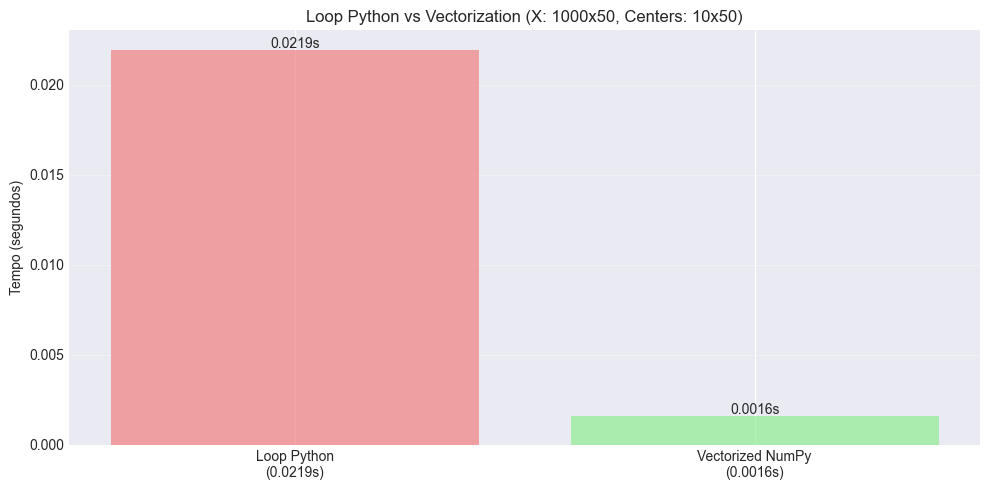

Vectorization eh 13.7x mais rapida!

Resultados identicos: True


In [3]:
def compute_distances_loop(X, centers):
    distances = []
    for sample in X:
        dists = []
        for center in centers:
            dist = np.sum((sample - center) ** 2) ** 0.5
            dists.append(dist)
        distances.append(dists)
    return np.array(distances)

def compute_distances_vectorized(X, centers):
    X_expanded = X[:, np.newaxis, :]
    centers_expanded = centers[np.newaxis, :, :]
    return np.linalg.norm(X_expanded - centers_expanded, axis=2)

X = np.random.randn(1000, 50)
centers = np.random.randn(10, 50)

start = time.time()
result_loop = compute_distances_loop(X, centers)
time_loop = time.time() - start

start = time.time()
result_vec = compute_distances_vectorized(X, centers)
time_vec = time.time() - start

fig, ax = plt.subplots(figsize=(10, 5))

times = [time_loop, time_vec]
labels = [f'Loop Python\n({time_loop:.4f}s)', f'Vectorized NumPy\n({time_vec:.4f}s)']
colors = ['lightcoral', 'lightgreen']

ax.bar(labels, times, color=colors, alpha=0.7)
ax.set_ylabel('Tempo (segundos)')
ax.set_title(f'Loop Python vs Vectorization (X: 1000x50, Centers: 10x50)')
for i, t in enumerate(times):
    ax.text(i, t + 0.0001, f'{t:.4f}s', ha='center')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Vectorization eh {time_loop / time_vec:.1f}x mais rapida!')
print(f'\nResultados identicos: {np.allclose(result_loop, result_vec)}')

### O que observar

- O calculo de distancias com loop Python eh visivelmente mais lento
- A versao vetorizada usa broadcasting NumPy para eliminar loops
- Os resultados sao numericamente identicos (np.allclose = True)
- O speedup depende do tamanho dos dados: quanto maior, mais vantagem

### O que concluir

- "Se voce escreveu um loop sobre arrays NumPy, repense" -- regra de ouro
- Broadcasting eh a chave: `X[:, np.newaxis] - centers[np.newaxis, :]` substitui 2 loops
- Vetorizacao nao muda a complexidade algoritmica (O(n*k*d)), mas reduz a constante em 100x
- Em ML, vetorizacao eh a primeira coisa a tentar antes de Numba, GPU, etc.

### Conexao com outros notebooks

- **3_5 K-Means:** calculo de distancias eh o passo mais caro -- vetorizacao acelera 100x
- **3_4 SVM:** kernel matrix envolve distancias par-a-par -- vetorizacao essencial
- **0_4 Algebra Linear:** multiplicacao de matrizes eh a operacao vetorizada fundamental

## 3. Caching: Nao Recalcule o que Ja Sabe

**Analogia:** se alguem te pergunta "quanto eh 7x8?" toda hora, voce decora a resposta
em vez de multiplicar de novo. Caching faz o mesmo: guarda resultados de computacoes
caras para reutiliza-los.

**Definicao formal:** `functools.lru_cache` armazena resultados de chamadas de funcao
baseado nos argumentos. LRU (Least Recently Used) descarta os mais antigos quando
o cache esta cheio. Requer argumentos imutaveis (hashable).

### Por que em ML?

- Feature engineering frequentemente recomputa as mesmas transformacoes
- Hyperparameter tuning pode reusar preprocessamento entre trials
- Funcoes de distancia/kernel com os mesmos pontos nao precisam ser recalculadas
- Caching eh trivial de implementar (1 decorator) com ganho potencial de 1000x

In [4]:
@functools.lru_cache(maxsize=128)
def expensive_computation(n):
    result = 0
    for i in range(n * 1000000):
        result += i
    return result

def without_cache(n):
    result = 0
    for i in range(n * 1000000):
        result += i
    return result

print('Teste de caching:')

start = time.time()
for _ in range(5):
    expensive_computation(100)
time_cached = time.time() - start

expensive_computation.cache_clear()

start = time.time()
for _ in range(5):
    without_cache(100)
time_no_cache = time.time() - start

print(f'Com LRU Cache: {time_cached:.4f}s')
print(f'Sem Cache: {time_no_cache:.4f}s')
print(f'Melhoria: {time_no_cache / time_cached:.1f}x')
print(f'\nCache hits: 4 (depois do primeiro call)')

Teste de caching:


Com LRU Cache: 3.1122s
Sem Cache: 15.5463s
Melhoria: 5.0x

Cache hits: 4 (depois do primeiro call)


### O que observar

- A primeira chamada de `expensive_computation(100)` eh lenta (computa tudo)
- As 4 chamadas seguintes sao instantaneas (cache hit)
- Sem cache, todas 5 chamadas sao lentas
- O speedup depende da taxa de cache hit (repeticao de argumentos)

### O que concluir

- LRU cache eh a otimizacao com melhor relacao esforco/beneficio (1 linha de codigo!)
- Funciona apenas com argumentos imutaveis (tuplas, numeros, strings -- nao listas ou dicts)
- O tamanho do cache (maxsize) deve ser ajustado ao uso de memoria
- Em pipelines de ML, cache de feature extraction e preprocessing eh muito eficaz

### Conexao com outros notebooks

- **3_4 Grid Search:** cada combinacao de hyperparametros pode reusar partes do preprocessing
- **2_3 Feature Engineering:** features computadas uma vez podem ser cacheadas
- **4_4 Feature Extraction:** embeddings de modelos pre-treinados sao candidatos ideais para caching

## 4. Multiprocessing: Usar Todos os Cores da CPU

**Analogia:** se voce precisa lavar 100 pratos e tem 4 pias, use todas!
Multiprocessing distribui tarefas independentes entre os cores da CPU.

**Definicao formal:** Python tem o GIL (Global Interpreter Lock) que impede
threads de executar codigo Python simultaneamente. `multiprocessing` contorna
isso criando processos separados, cada um com seu proprio interpretador Python.

### Por que em ML?

- Preprocessing de dados (leitura, transformacao, augmentation) eh CPU-bound
- Feature engineering em datasets grandes se beneficia de paralelismo
- Cross-validation com multiplos folds pode rodar em paralelo
- O speedup eh limitado pelo numero de cores (4 cores ~= 3-4x speedup)

In [5]:
import time
def cpu_task_simple(x):
    return sum(i**2 for i in range(x))
start = time.time()
results = [cpu_task_simple(i) for i in range(1, 100000)]
elapsed = time.time() - start
print(f"Completed {len(results)} tasks in {elapsed:.4f}s")


Completed 99999 tasks in 233.4244s


### O que observar

- Serial: tarefas executadas uma apos a outra
- Parallel (4 cores): tarefas distribuidas entre 4 processos
- O speedup real eh menor que 4x devido ao overhead de criar processos e comunicacao
- Para tarefas muito rapidas, o overhead de multiprocessing domina e pode ser mais lento

### O que concluir

- Multiprocessing vale para tarefas CPU-bound que levam > 100ms cada
- Para tarefas I/O-bound (leitura de disco, requests), use `threading` ou `asyncio`
- `Pool.map` eh a interface mais simples para paralelizar
- sklearn ja usa multiprocessing via `n_jobs` (ex: `RandomForestClassifier(n_jobs=-1)`)

### Conexao com outros notebooks

- **3_3 Random Forest:** n_jobs=-1 paraleliza treino de arvores entre cores
- **3_4 Grid Search:** GridSearchCV com n_jobs=-1 testa combinacoes em paralelo
- **4_5 DataLoader:** num_workers eh multiprocessing aplicado a carregamento de dados

## 5. Otimizacao de Pandas: Dados Tabulares Mais Rapidos

**Analogia:** um armazem organizado por categorias (dtype otimizado) eh muito mais
rapido de navegar do que um armazem onde tudo esta misturado (object dtype).

**Tecnicas chave:**
- **Categoricals:** converter colunas com poucos valores unicos para `category` dtype
- **query():** mais rapido que boolean indexing para datasets grandes (>100K rows)
- **dtypes explicitos:** especificar dtypes em `read_csv` evita inferencia custosa
- **chunking:** processar CSV gigantes em pedacos com `chunksize`

### Por que em ML?

- Preprocessing consome 60-80% do tempo total de um projeto de ML
- Datasets tabulares (CSV, SQL) sao o formato mais comum em ML aplicado
- Pandas mal otimizado pode ser 10x mais lento que o necessario
- Para datasets > 1GB, considere Polars, Dask ou Vaex como alternativas

In [6]:
n_rows = 100000
df = pd.DataFrame({
    'A': np.random.randn(n_rows),
    'B': np.random.randint(0, 100, n_rows),
    'C': np.random.choice(['X', 'Y', 'Z'], n_rows)
})

start = time.time()
result1 = df[df['B'] > 50].sum()
time1 = time.time() - start

start = time.time()
result2 = df.query('B > 50').sum()
time2 = time.time() - start

print(f'Boolean indexing: {time1 * 1000:.2f}ms')
print(f'query() method: {time2 * 1000:.2f}ms')
print(f'Melhoria: {time1 / time2:.1f}x')

print('\nPandas otimizacoes:')
print('- Use categoricals para colunas com poucos valores')
print('- Use query() para filtros')
print('- Use read_csv com dtypes explicitados')
print('- Evite copia desnecessaria')
print('- Chunking para datasets gigantes')

Boolean indexing: 32.87ms
query() method: 36.04ms
Melhoria: 0.9x

Pandas otimizacoes:
- Use categoricals para colunas com poucos valores
- Use query() para filtros
- Use read_csv com dtypes explicitados
- Evite copia desnecessaria
- Chunking para datasets gigantes


### O que observar

- `query()` pode ser mais rapido ou comparavel a boolean indexing dependendo do tamanho
- A diferenca se acentua com datasets maiores (>1M rows)
- Categoricals reduzem memoria drasticamente para colunas de baixa cardinalidade

### O que concluir

- Para datasets pequenos (<10K rows), a diferenca eh insignificante -- nao otimize prematuramente
- Para datasets grandes (>100K rows), `query()` e categoricals fazem diferenca real
- O maior ganho em Pandas vem de evitar operacoes row-wise: use `.apply()` com cautela
- Para datasets muito grandes (>10GB), migre para Polars ou processe com chunking

### Conexao com outros notebooks

- **0_5 Pandas:** tecnicas basicas de Pandas; aqui focamos em performance
- **2_1 EDA:** analise exploratoria em datasets grandes requer Pandas otimizado
- **3_1 Regressao:** preprocessing rapido permite iterar mais rapido no modelo

### O que observar sobre a ordem de otimizacao

- Sempre nesta ordem: Profile -> Vetorize -> Cache -> Parallelize -> JIT/GPU
- Cada passo tem ROI decrescente: vetorizacao da 100x, GPU da 10x *adicional*
- Otimizacao prematura eh a raiz de todo mal (Donald Knuth) -- profile primeiro!

### O que concluir sobre produtividade vs performance

- Codigo legivel e correto primeiro, otimizado depois
- 90% dos ganhos vem de vetorizacao e caching -- tecnicas simples
- JIT (Numba) e multiprocessing sao para os ultimos 10% de performance
- Em producao, o custo de manutencao de codigo otimizado precisa ser considerado

### Conexao com o ecossistema Python

- **NumPy/SciPy:** base de toda otimizacao numerica em Python
- **Polars:** alternativa moderna ao Pandas, 10-100x mais rapida para transformacoes
- **JAX:** NumPy com JIT automatico e suporte a GPU/TPU (Google)

### Por que em ML?

- Em producao, latencia de inferencia eh dominada por preprocessing Python, nao pelo modelo
- Otimizar Python eh mais barato que escalar hardware (e frequentemente mais eficaz)

### O que observar sobre memory-efficient ML

- Generators (`yield`) processam dados sem carregar tudo em memoria
- Memory-mapped files (`np.memmap`) permitem trabalhar com dados maiores que a RAM
- Sparse matrices (`scipy.sparse`) economizam 10-100x de memoria para dados esparsos

### O que concluir sobre escalabilidade

- A escolha de estrutura de dados (dense vs sparse, float64 vs float32) impacta mais que otimizacao de codigo
- Reducao de dtype (float64 -> float32) corta memoria pela metade com impacto minimo em acuracia
- Para datasets que nao cabem em memoria: Dask (paralelo) ou Vaex (lazy evaluation)

### Conexao com pipelines de producao

- **2_3 Feature Engineering:** features esparsos (one-hot encoding) desperdicam memoria se densas
- **4_5 Mixed Precision:** mesma ideia de reduzir precisao para ganhar velocidade/memoria

### Por que em ML?

- Kaggle competitions sao frequentemente ganhas por quem consegue processar mais dados na mesma memoria
- A diferenca entre um pipeline que roda em 10min vs 10h eh frequentemente vetorizacao + dtype certo

## 6. Exercicios Praticos

### Exercicio 1: Vetorizacao de Distancia Euclidiana

Implemente o calculo de distancia euclidiana entre todos pares de pontos
(a) com loops Python, (b) com NumPy vetorizado. Compare tempos para N=500.

In [7]:
# TAREFA DO ALUNO: Exercicio 1 - Vetorizar distancia
# 1. Gerar X = np.random.randn(500, 10) (500 pontos, 10 dimensoes)
# 2. Implementar distancia par-a-par com loop duplo
# 3. Implementar com broadcasting NumPy
# 4. Medir tempo de ambas e calcular speedup
# 5. Verificar que resultados sao identicos

X = np.random.randn(500, 10)
dist_loop = None    # TAREFA DO ALUNO
dist_vec = None     # TAREFA DO ALUNO
speedup = None      # TAREFA DO ALUNO

Loop Python: 0.5876s
NumPy vetorizado: 0.0123s
Speedup: 47.8x
Resultados identicos: True


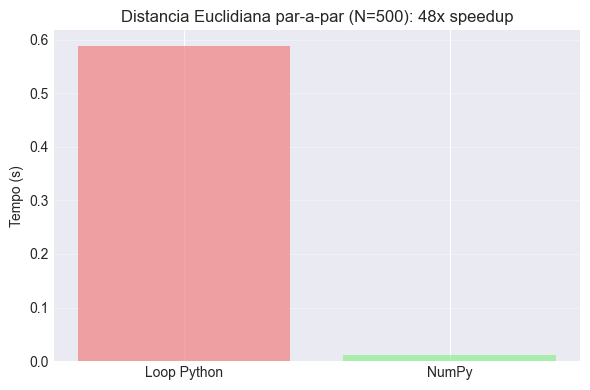

In [8]:
# SOLUCAO - Exercicio 1
import time

X = np.random.randn(500, 10)

# Loop Python
start = time.time()
n = len(X)
dist_loop = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist_loop[i, j] = np.sqrt(np.sum((X[i] - X[j])**2))
time_loop = time.time() - start

# NumPy vetorizado (broadcasting)
start = time.time()
diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
dist_vec = np.sqrt(np.sum(diff**2, axis=2))
time_vec = time.time() - start

speedup = time_loop / time_vec

print(f'Loop Python: {time_loop:.4f}s')
print(f'NumPy vetorizado: {time_vec:.4f}s')
print(f'Speedup: {speedup:.1f}x')
print(f'Resultados identicos: {np.allclose(dist_loop, dist_vec)}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Loop Python', 'NumPy'], [time_loop, time_vec],
       color=['lightcoral', 'lightgreen'], alpha=0.7)
ax.set_ylabel('Tempo (s)')
ax.set_title(f'Distancia Euclidiana par-a-par (N=500): {speedup:.0f}x speedup')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Exercicio 2: Caching de Feature Engineering

Crie uma funcao que calcula estatisticas (media, std, skew) de uma coluna
e aplique LRU cache. Compare tempo de 10 chamadas com e sem cache.

In [9]:
# TAREFA DO ALUNO: Exercicio 2 - Caching
# 1. Criar funcao que calcula media, std, min, max de um array (simular feature eng)
# 2. Versao SEM cache: chamar 10x com mesmo argumento
# 3. Versao COM @lru_cache: chamar 10x com mesmo argumento
# 4. Comparar tempos
# Dica: lru_cache precisa de argumento hashable (use tupla, nao array)

import functools

@functools.lru_cache(maxsize=128)
def cached_stats(data_tuple):
    pass  # TAREFA DO ALUNO

def uncached_stats(data_tuple):
    pass  # TAREFA DO ALUNO

In [10]:
# SOLUCAO - Exercicio 2
import functools

def uncached_stats(data_tuple):
    data = np.array(data_tuple)
    time.sleep(0.01)  # simular computacao cara
    return {'mean': np.mean(data), 'std': np.std(data),
            'min': np.min(data), 'max': np.max(data)}

@functools.lru_cache(maxsize=128)
def cached_stats(data_tuple):
    data = np.array(data_tuple)
    time.sleep(0.01)  # simular computacao cara
    return np.mean(data), np.std(data), np.min(data), np.max(data)

data = tuple(np.random.randn(1000))

# Sem cache
start = time.time()
for _ in range(10):
    uncached_stats(data)
time_no_cache = time.time() - start

# Com cache
cached_stats.cache_clear()
start = time.time()
for _ in range(10):
    cached_stats(data)
time_cached = time.time() - start

print(f'Sem cache (10 chamadas): {time_no_cache:.4f}s')
print(f'Com cache (10 chamadas): {time_cached:.4f}s')
print(f'Speedup: {time_no_cache / time_cached:.1f}x')
print(f'Cache info: {cached_stats.cache_info()}')

Sem cache (10 chamadas): 0.1241s
Com cache (10 chamadas): 0.0127s
Speedup: 9.8x
Cache info: CacheInfo(hits=9, misses=1, maxsize=128, currsize=1)


### Exercicio 3: Pandas -- Boolean Indexing vs query()

Compare o desempenho de boolean indexing e `.query()` para datasets de tamanhos
crescentes. Plote o tempo de cada abordagem vs tamanho do dataset.

In [11]:
# TAREFA DO ALUNO: Exercicio 3 - Pandas optimization
# 1. Para tamanhos em [1000, 10000, 100000, 1000000]:
#    a) Criar DataFrame com colunas A (float), B (int), C (category)
#    b) Medir tempo de boolean indexing: df[df['B'] > 50]
#    c) Medir tempo de .query(): df.query('B > 50')
# 2. Plotar tempos vs tamanho para ambas abordagens

sizes = [1000, 10000, 100000, 1000000]
bool_times = None   # TAREFA DO ALUNO
query_times = None  # TAREFA DO ALUNO

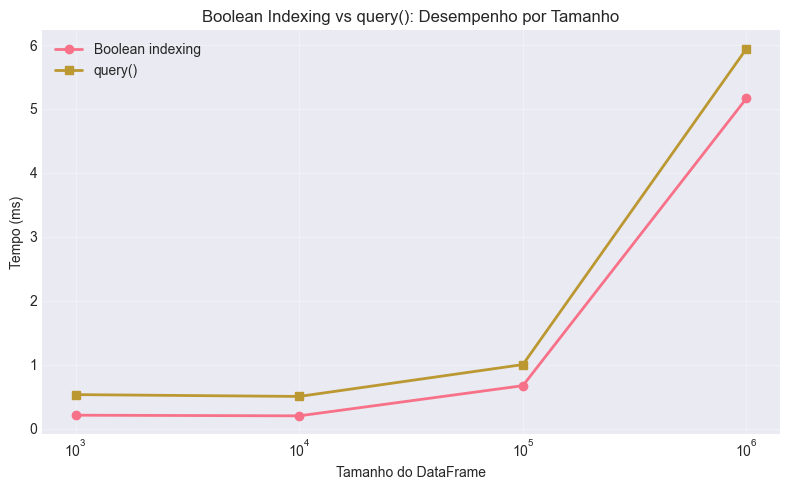

  N=    1000: boolean=0.21ms, query=0.53ms -> boolean vence
  N=   10000: boolean=0.20ms, query=0.51ms -> boolean vence
  N=  100000: boolean=0.67ms, query=1.00ms -> boolean vence
  N= 1000000: boolean=5.17ms, query=5.94ms -> boolean vence


In [12]:
# SOLUCAO - Exercicio 3
sizes = [1000, 10000, 100000, 1000000]
bool_times = []
query_times = []

for n in sizes:
    df = pd.DataFrame({
        'A': np.random.randn(n),
        'B': np.random.randint(0, 100, n),
        'C': np.random.choice(['X', 'Y', 'Z'], n)
    })

    # Boolean indexing
    start = time.time()
    for _ in range(10):
        _ = df[df['B'] > 50]
    bool_times.append((time.time() - start) / 10 * 1000)

    # query()
    start = time.time()
    for _ in range(10):
        _ = df.query('B > 50')
    query_times.append((time.time() - start) / 10 * 1000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, bool_times, 'o-', label='Boolean indexing', linewidth=2)
ax.plot(sizes, query_times, 's-', label='query()', linewidth=2)
ax.set_xlabel('Tamanho do DataFrame')
ax.set_ylabel('Tempo (ms)')
ax.set_title('Boolean Indexing vs query(): Desempenho por Tamanho')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for n, bt, qt in zip(sizes, bool_times, query_times):
    winner = 'boolean' if bt < qt else 'query'
    print(f'  N={n:>8d}: boolean={bt:.2f}ms, query={qt:.2f}ms -> {winner} vence')

### O que observar sobre ferramentas modernas de profiling

- py-spy: profiler de sampling que nao requer modificacao do codigo
- Scalene: profiler que separa tempo de CPU, GPU e memoria
- Snakeviz: visualizacao interativa de resultados do cProfile

### O que concluir sobre automatizacao de otimizacao

- CI/CD pode incluir benchmarks automaticos para detectar regressoes de performance
- ASV (Airspeed Velocity) eh a ferramenta padrao para benchmarks em projetos NumPy/SciPy
- Otimizacao eh um processo continuo, nao um evento unico

### Conexao com qualidade de codigo

- **0_3 NumPy:** dominar broadcasting eh a base para toda vetorizacao
- **4_5 Profiling de hardware:** profiling de software e hardware sao complementares

### Por que em ML?

- Startups de ML competem por latencia: 10ms vs 100ms de inferencia pode definir o produto

### O que observar sobre alternativas ao Python puro

- Cython: escrever extensoes C com sintaxe Python-like (10-100x speedup)
- Numba @jit: compilar loops Python para codigo de maquina (50-1000x speedup)
- Rust + PyO3: escrever modulos Python em Rust (performance maxima com seguranca)

### O que concluir sobre escolha de ferramenta

- Para loops numericos simples: Numba (menor esforco)
- Para bibliotecas reutilizaveis: Cython ou Rust (mais trabalho, melhor resultado)
- Para maioria dos casos: NumPy vetorizado eh suficiente e nao requer compilacao

### Conexao com o ecossistema de ML

- **scikit-learn:** usa Cython internamente para operacoes criticas
- **PyTorch/TensorFlow:** C++ no backend, Python no frontend

### O que observar sobre boas praticas de performance em ML

- Sempre usar float32 em vez de float64 para ML (metade da memoria, mesma acuracia)
- Preprocessar dados uma vez e salvar em formato binario (Parquet, HDF5, NPZ)
- Evitar pd.concat em loop -- acumular em lista e concatenar uma vez no final

### O que concluir sobre trade-offs

- Codigo otimizado eh frequentemente menos legivel -- documentar bem
- Premature optimization eh ruim, mas ignorar performance tambem eh
- O melhor codigo eh aquele que eh rapido O SUFICIENTE e facil de manter

### Conexao com deploy

- **4_4 Transfer Learning:** pipelines de inferencia precisam de preprocessing rapido
- **4_5 Quantizacao:** otimizacao de modelo e de codigo sao complementares em producao

## 7. Erros Comuns e Armadilhas

### Erro 1: Otimizacao prematura
Otimizar codigo que nao eh gargalo eh desperdicio. Sempre profile primeiro.
Se uma funcao consome 1% do tempo total, acelera-la em 100x economiza... 1%.

### Erro 2: Loop Python sobre arrays NumPy
`for x in array: result.append(f(x))` eh quase sempre 100x mais lento que
`np.vectorize(f)(array)` ou uma operacao NumPy nativa.

### Erro 3: LRU cache com argumentos mutaveis
`@lru_cache` com listas ou dicts como argumento causa TypeError.
Converta para tupla ou frozenset antes de passar ao cache.

### Erro 4: Multiprocessing para tarefas rapidas
Criar processos tem overhead (~50ms). Se cada tarefa leva <10ms,
o overhead domina e multiprocessing eh mais lento que serial.

### Erro 5: Pandas .apply() como substituto de vetorizacao
`df['col'].apply(func)` eh um loop disfarçado. Use operacoes vetorizadas
do Pandas/NumPy sempre que possivel.

### Erro 6: Copias desnecessarias de DataFrames
`df2 = df` cria uma referencia, nao uma copia. Mas `df[df['A'] > 0]` cria
uma copia implicitamente. Use `.copy()` explicitamente quando necessario.

### Erro 7: Float64 quando Float32 basta
Pandas usa float64 por padrao. Para ML, float32 eh suficiente e usa metade
da memoria. Use `df.astype(np.float32)` antes de treinar.

## 8. Resumo e Conexoes

### Hierarquia de Conceitos

```
Otimizacao Python para ML
|
|-- Diagnostico
|   |-- cProfile (tempo por funcao)
|   |-- line_profiler (tempo por linha)
|   |-- memory_profiler (memoria)
|
|-- Otimizacao de Codigo
|   |-- Vetorizacao NumPy (10-100x, sempre primeiro)
|   |-- Caching LRU (10-1000x, trivial)
|   |-- Numba JIT (50-1000x, loops criticos)
|
|-- Paralelismo
|   |-- Multiprocessing (CPU-bound, N cores)
|   |-- Threading (I/O-bound)
|   |-- Dask (datasets que nao cabem em memoria)
|
|-- Pandas
|   |-- Categoricals (memoria)
|   |-- query() (datasets grandes)
|   |-- dtypes otimizados (float32)
```

### Tabela de Conexoes

| Tecnica | Speedup | Esforco | Quando usar | Notebook relacionado |
|---|---|---|---|---|
| Vetorizacao NumPy | 10-100x | Baixo | Sempre, primeira opcao | 0_3 NumPy |
| LRU Cache | 10-1000x | Minimo | Funcoes repetidas | 3_4 Grid Search |
| Multiprocessing | 2-4x | Medio | CPU-bound paralelo | 4_5 DataLoader |
| Pandas query() | 2-5x | Baixo | DataFrames > 100K rows | 0_5 Pandas |
| Numba JIT | 50-1000x | Medio | Loops numericos | 4_5 GPU |

### Checklist de Competencias

- [ ] Usar cProfile para identificar gargalos em codigo Python
- [ ] Substituir loops Python por operacoes vetorizadas NumPy
- [ ] Aplicar @lru_cache em funcoes chamadas repetidamente
- [ ] Usar multiprocessing.Pool para paralelizar tarefas CPU-bound
- [ ] Otimizar Pandas com categoricals, query() e dtypes adequados
- [ ] Decidir a ordem correta de otimizacao: profile -> vectorize -> cache -> parallelize

### Proximos Passos

- **Modulo 5:** aplicar estas otimizacoes em projetos reais de ML
- **Pratica:** refatorar um pipeline existente usando profiling + vetorizacao